# ChemAI: Predict the Cure

Разработка новых лекарственных препаратов — сложный и длительный процесс, включающий синтез соединений и их биологическое тестирование. Современные методы машинного обучения позволяют ускорить этот процесс, предсказывая эффективность химических соединений до проведения лабораторных экспериментов.

Химики предоставили данные о свойствах молекул и их биологической активности против вируса гриппа. Наша задача — построить модели, способные предсказывать эффективность новых соединений.

Работу выполнила команда Data Seven:
- Леонид Найданов (Team Lead, Data Analyst)
- Роман Гусарь (Data Engineer)
- Сергей Соловьев (Machine Learning Engineer)

In [1]:
# Подключаем src/ из корня репо
import sys
sys.path.append("..")

In [2]:
# Стандартные библиотеки
import json
import warnings
from collections import defaultdict

# Сторонние библиотеки
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [3]:
# Настройка путей к файлам и директориям
from pathlib import Path

_NB_DIR = Path().resolve()

# Определяем корень проекта
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == 'notebooks' else _NB_DIR

# Основные директории проекта
# Директория с сырыми данными
RAW_DIR = REPO_ROOT / 'data' / 'raw'

# Директория с обработанными данными
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'

# Директория для файлов сабмитов
SUBMISSIONS_DIR = REPO_ROOT / 'data' / 'submissions'

# Директория для артефактов моделей
ARTIFACTS_DIR = REPO_ROOT / 'artifacts'

# Создание директорий
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

## Загрузка исходных данных

In [4]:
train_df = pd.read_csv(RAW_DIR / f'train.csv')
test_df = pd.read_csv(RAW_DIR / f'test.csv')

In [5]:
print(f"Размер обучающей выборки: {train_df.shape[0]} строк, {train_df.shape[1]} столбцов")
print(f"Размер тестовой выборки: {test_df.shape[0]} строк, {test_df.shape[1]} столбцов")

Размер обучающей выборки: 751 строк, 214 столбцов
Размер тестовой выборки: 250 строк, 211 столбцов


In [6]:
train_df.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Типы данных
train_df.dtypes.value_counts()

int64      107
float64    107
Name: count, dtype: int64

## Иследование и анализ исходных данных

### Проверка на пропуски

In [8]:
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0]
missing_test = test_df.isnull().sum()
missing_test = missing_test[missing_test > 0]

print(f"Пропуски в train: {len(missing_train)} столбцов")
print(f"Пропуски в test: {len(missing_test)} столбцов")

Пропуски в train: 12 столбцов
Пропуски в test: 12 столбцов


### Статистика целевых переменных

In [9]:
TARGET_COLS     = ['IC50', 'CC50', 'SI']
RAW_TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']
INDEX_COL       = 'index'

In [10]:
for col in RAW_TARGET_COLS:
    print(f"\n{col}:")
    print(f"  Среднее: {train_df[col].mean():.4f}")
    print(f"  Медиана: {train_df[col].median():.4f}")
    print(f"  Стандартное отклонение: {train_df[col].std():.4f}")
    print(f"  Минимум: {train_df[col].min():.4f}")
    print(f"  Максимум: {train_df[col].max():.4f}")
    print(f"  Коэффициент вариации: {train_df[col].std()/train_df[col].mean():.4f}")


IC50, mM:
  Среднее: 204.5440
  Медиана: 44.0693
  Стандартное отклонение: 370.3679
  Минимум: 0.0035
  Максимум: 4095.1886
  Коэффициент вариации: 1.8107

CC50, mM:
  Среднее: 577.4261
  Медиана: 376.5809
  Стандартное отклонение: 641.5152
  Минимум: 0.7008
  Максимум: 4538.9762
  Коэффициент вариации: 1.1110

SI:
  Среднее: 89.1533
  Медиана: 4.0000
  Стандартное отклонение: 788.8822
  Минимум: 0.0115
  Максимум: 15620.6000
  Коэффициент вариации: 8.8486


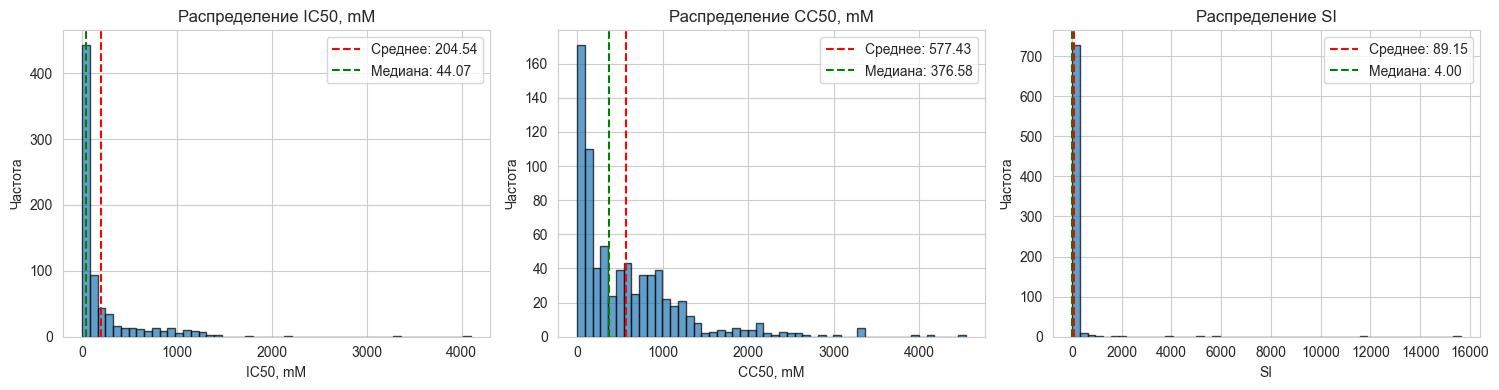

In [11]:
# Визуализация распределения целевых переменных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(RAW_TARGET_COLS):
    axes[i].hist(train_df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].axvline(train_df[col].mean(), color='red', linestyle='--', label=f'Среднее: {train_df[col].mean():.2f}')
    axes[i].axvline(train_df[col].median(), color='green', linestyle='--', label=f'Медиана: {train_df[col].median():.2f}')
    axes[i].legend()
plt.tight_layout()

### Анализ признаков

In [12]:
# Выбираем ключевые химические признаки для демонстрации
key_features = ['MolWt', 'qed', 'HeavyAtomCount', 'NumHAcceptors',
                'NumHDonors', 'NumRotatableBonds', 'RingCount', 'MolLogP', 'TPSA']

In [13]:
# Статистика для ключевых молекулярных дескрипторов
for col in key_features:
    if col in train_df.columns:
        print(f"\n{col}:")
        print(f"    Диапазон: [{train_df[col].min():.2f}, {train_df[col].max():.2f}]")
        print(f"    Среднее: {train_df[col].mean():.2f} ± {train_df[col].std():.2f}")


MolWt:
    Диапазон: [110.16, 904.78]
    Среднее: 352.41 ± 129.07

qed:
    Диапазон: [0.06, 0.95]
    Среднее: 0.58 ± 0.21

HeavyAtomCount:
    Диапазон: [8.00, 63.00]
    Среднее: 24.95 ± 9.21

NumHAcceptors:
    Диапазон: [0.00, 25.00]
    Среднее: 4.37 ± 3.25

NumHDonors:
    Диапазон: [0.00, 15.00]
    Среднее: 1.20 ± 1.61

NumRotatableBonds:
    Диапазон: [0.00, 28.00]
    Среднее: 3.89 ± 3.27

RingCount:
    Диапазон: [0.00, 9.00]
    Среднее: 3.62 ± 1.60

MolLogP:
    Диапазон: [-5.75, 12.82]
    Среднее: 3.46 ± 2.14

TPSA:
    Диапазон: [0.00, 407.50]
    Среднее: 61.91 ± 46.38


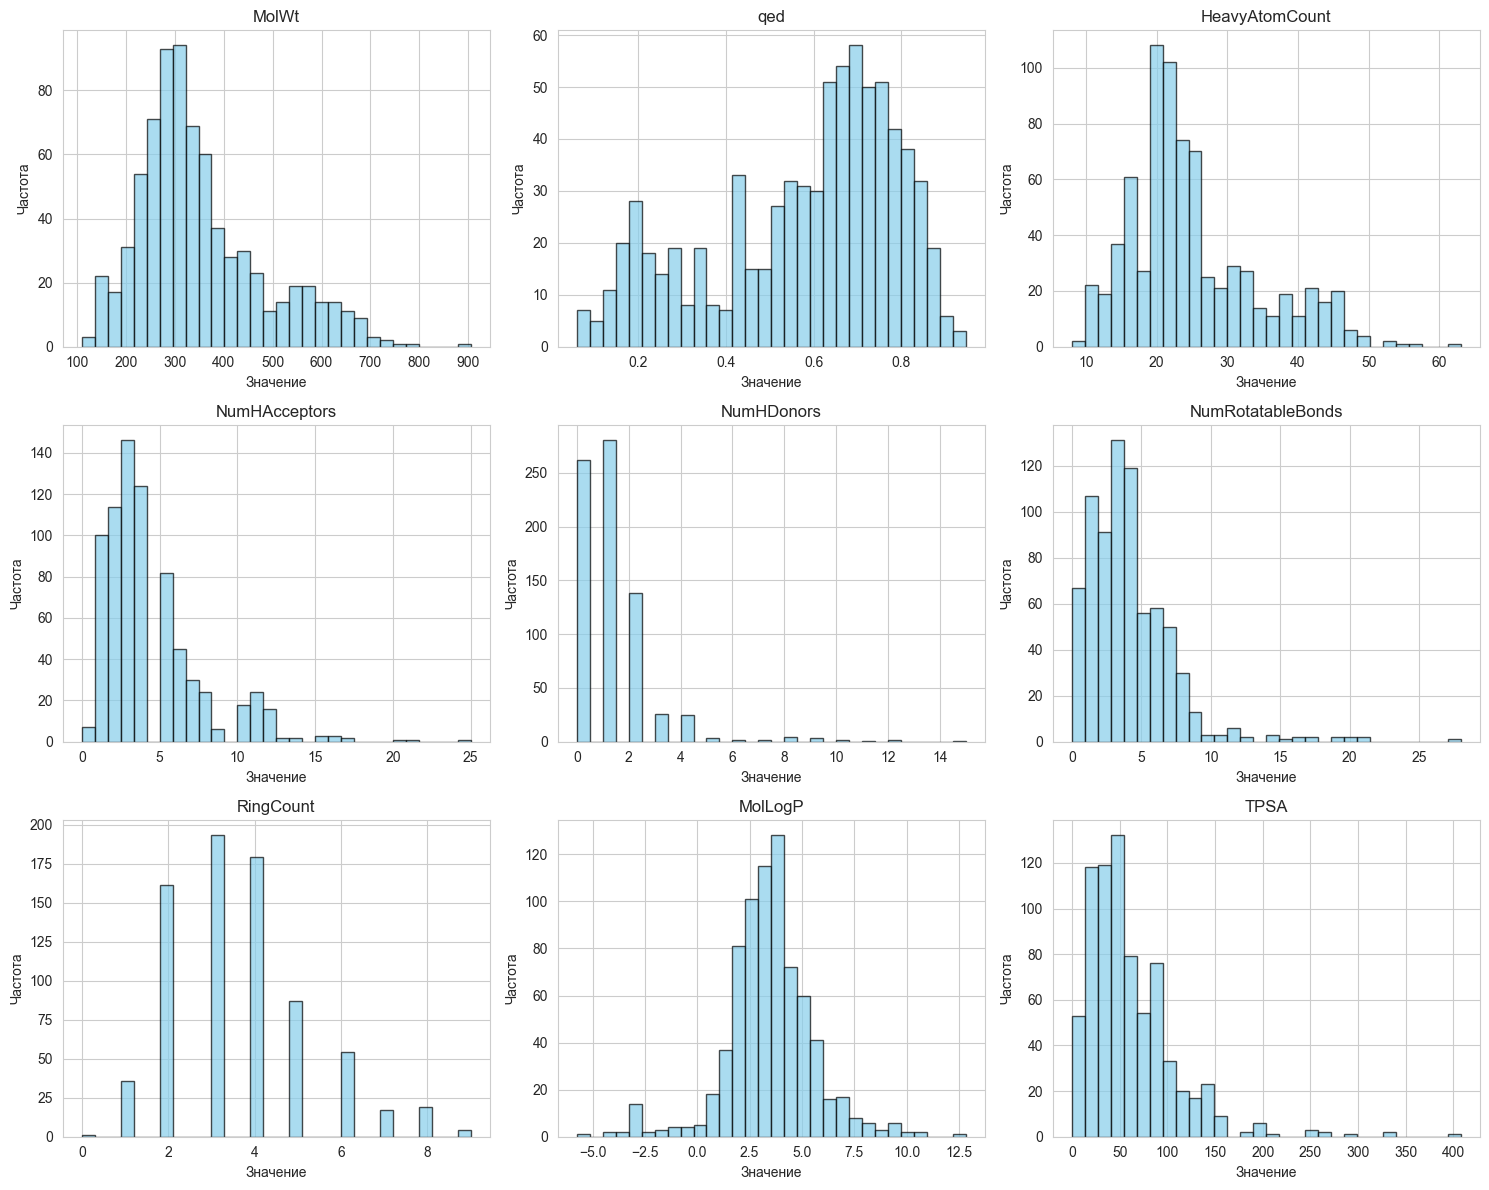

In [14]:
# Визуализация распределений ключевых признаков
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(key_features[:9]):
    if col in train_df.columns:
        axes[i].hist(train_df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[i].set_title(col)
        axes[i].set_xlabel('Значение')
        axes[i].set_ylabel('Частота')
plt.tight_layout()

### Проверка на выбросы

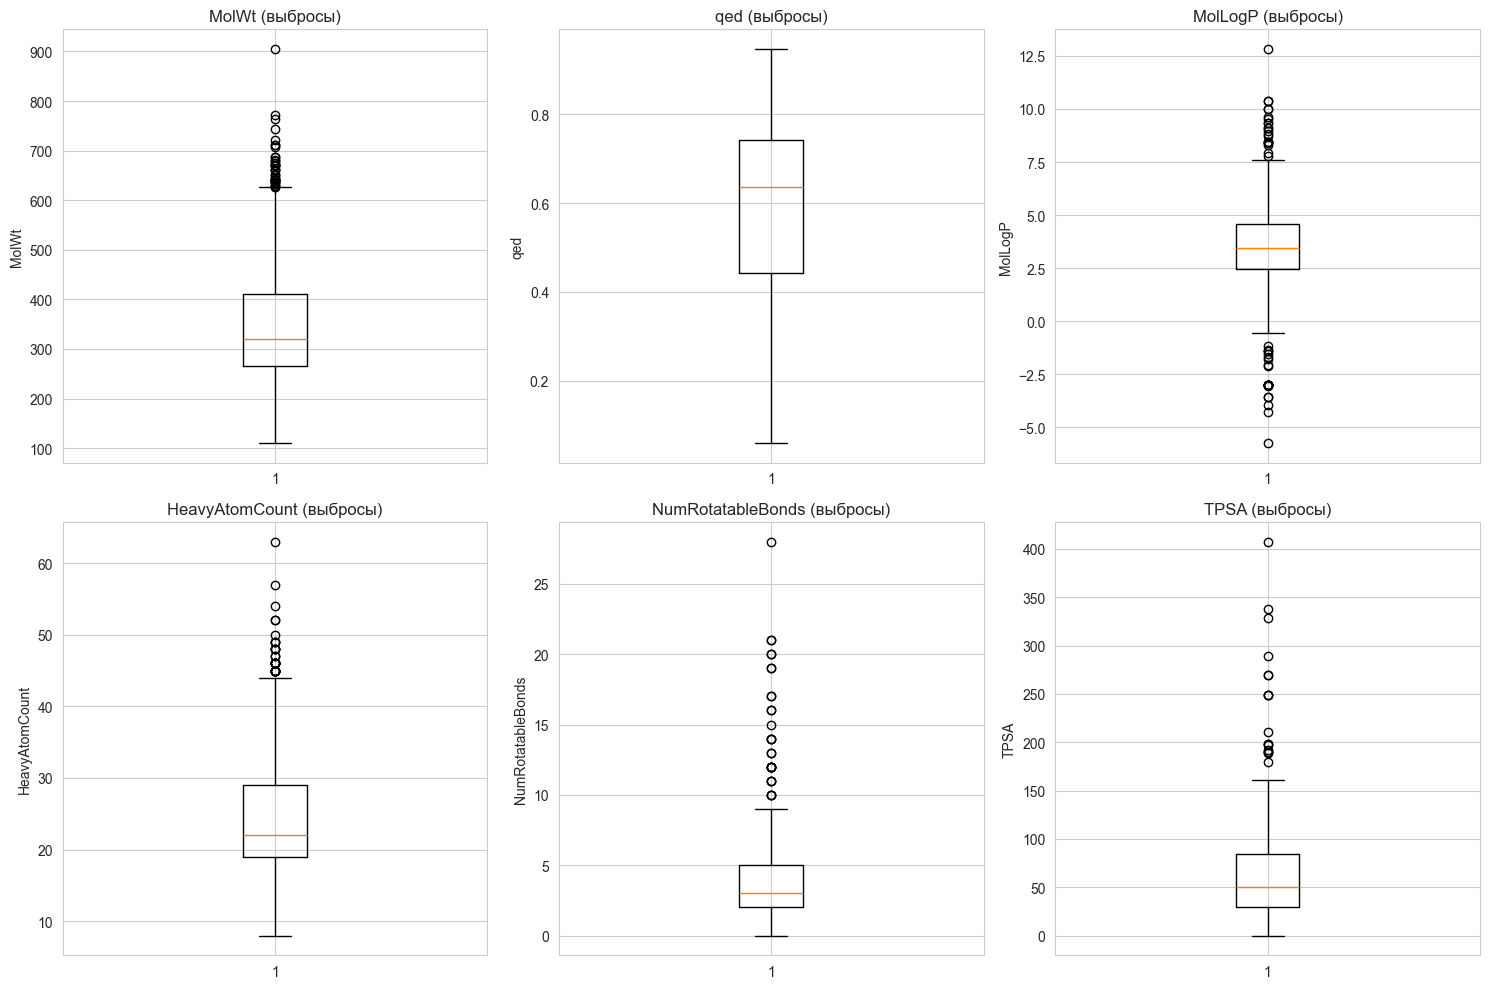

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
features_for_boxplot = ['MolWt', 'qed', 'MolLogP', 'HeavyAtomCount', 'NumRotatableBonds', 'TPSA']
for i, col in enumerate(features_for_boxplot):
    if col in train_df.columns:
        axes[i].boxplot(train_df[col], vert=True)
        axes[i].set_title(f'{col} (выбросы)')
        axes[i].set_ylabel(col)
plt.tight_layout()

In [16]:
# Функция для подсчета выбросов по методу IQR
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

In [17]:
# Количество выбросов (по методу IQR) в ключевых признаках
for col in features_for_boxplot:
    if col in train_df.columns:
        n_outliers = count_outliers_iqr(train_df, col)
        print(f"  {col}: {n_outliers} выбросов ({n_outliers/len(train_df)*100:.1f}%)")

  MolWt: 36 выбросов (4.8%)
  qed: 0 выбросов (0.0%)
  MolLogP: 49 выбросов (6.5%)
  HeavyAtomCount: 35 выбросов (4.7%)
  NumRotatableBonds: 29 выбросов (3.9%)
  TPSA: 18 выбросов (2.4%)


### Корреляционный анализ

In [18]:
# Корреляции целевых переменных между собой
target_corr = train_df[RAW_TARGET_COLS].corr()

target_corr.round(4)

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.0000,0.4704,-0.0605
"CC50, mM",0.4704,1.0000,-0.0057
SI,-0.0605,-0.0057,1.0000


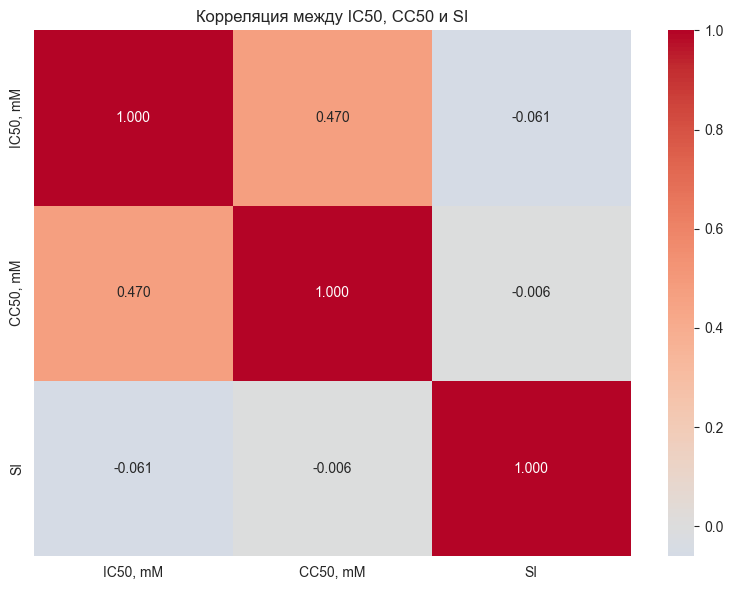

In [19]:
# Визуализация корреляционной матрицы целей
plt.figure(figsize=(8, 6))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Корреляция между IC50, CC50 и SI')
plt.tight_layout()

In [20]:
# Топ-10 признаков, наиболее коррелирующих с IC50
feature_cols = [col for col in train_df.columns if col not in RAW_TARGET_COLS + [INDEX_COL]]
corr_with_IC50 = train_df[feature_cols].corrwith(train_df['IC50, mM']).abs().sort_values(ascending=False).head(10)
corr_with_IC50

VSA_EState4    0.244974
Chi2n          0.224854
Chi2v          0.220377
PEOE_VSA7      0.217539
Chi4v          0.214185
Chi4n          0.211763
Chi3v          0.211360
Chi3n          0.211065
SlogP_VSA5     0.205050
Chi1n          0.204975
dtype: float64

In [21]:
# Топ-10 признаков, наиболее коррелирующих с CC50
corr_with_CC50 = train_df[feature_cols].corrwith(train_df['CC50, mM']).abs().sort_values(ascending=False).head(10)
corr_with_CC50

LabuteASA              0.306634
MolMR                  0.306621
Chi0                   0.305092
MolWt                  0.305003
ExactMolWt             0.304977
Kappa1                 0.304825
HeavyAtomCount         0.303823
Kappa2                 0.302823
Chi1                   0.302402
NumValenceElectrons    0.302281
dtype: float64

In [22]:
# Топ-10 признаков, наиболее коррелирующих с SI
corr_with_SI = train_df[feature_cols].corrwith(train_df['SI']).abs().sort_values(ascending=False).head(10)
corr_with_SI

BalabanJ            0.188212
fr_NH2              0.176325
RingCount           0.141653
fr_Al_COO           0.112759
fr_COO2             0.110985
fr_COO              0.110985
FpDensityMorgan1    0.102769
VSA_EState4         0.098813
NumAromaticRings    0.097596
VSA_EState6         0.093144
dtype: float64

In [23]:
# Выбираем признаки с наибольшей дисперсией (топ-20)
variances = train_df[feature_cols].var().sort_values(ascending=False).head(20)
top_features = variances.index.tolist() + RAW_TARGET_COLS
corr_matrix = train_df[top_features].corr()

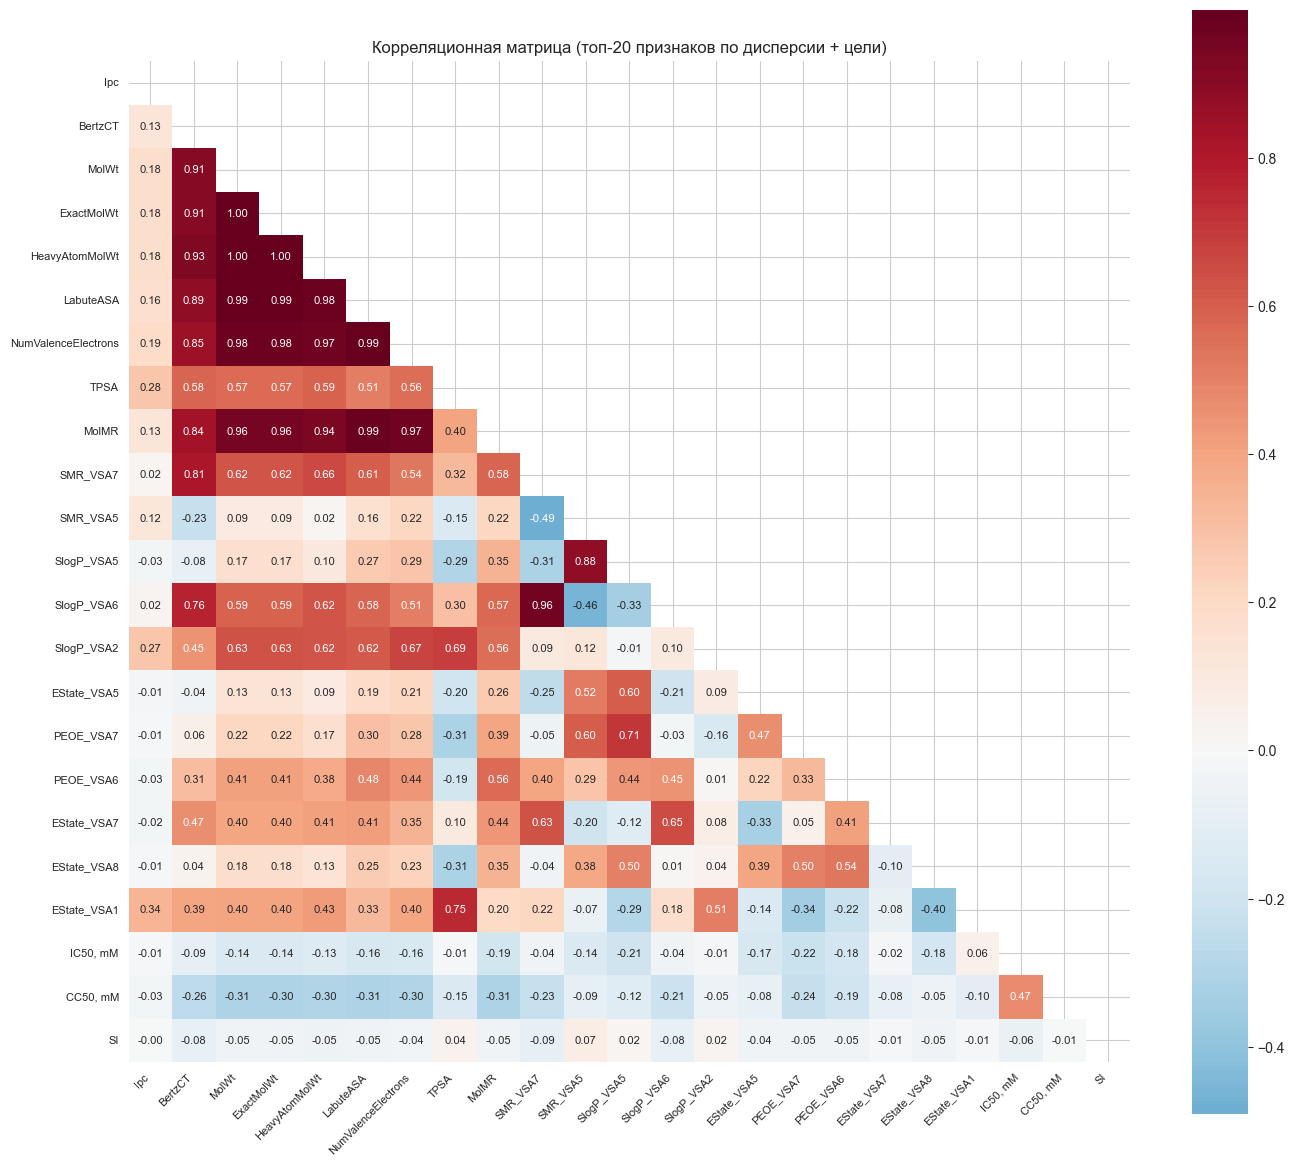

In [24]:
# Визуализация корреляционной матрицы (выборочно, топ-20 признаков по дисперсии)
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, annot_kws={'size': 8})
plt.title('Корреляционная матрица (топ-20 признаков по дисперсии + цели)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

### Анализ по типу соединений

In [25]:
# Ищем категориальные признаки (тип object)
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

[]

### Сводная статистика по всему датасету

In [26]:
# Количество признаков по типам
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовых признаков: {len(numeric_cols)}")

Числовых признаков: 214


In [27]:
# Диапазоны значений (мин/макс) для всех признаков
ranges = pd.DataFrame({
    'min': train_df[numeric_cols].min(),
    'max': train_df[numeric_cols].max(),
    'range': train_df[numeric_cols].max() - train_df[numeric_cols].min()
}).sort_values('range', ascending=False)

In [28]:
# Топ-10 признаков с наибольшим разбросом значений
ranges.head(10)

,min,max,range
Ipc,107.107191,3.951781e+13,3.951781e+13
SI,0.011489,1.562060e+04,1.562059e+04
"CC50, mM",0.700808,4.538976e+03,4.538275e+03
"IC50, mM",0.003517,4.095189e+03,4.095185e+03
BertzCT,128.348516,2.263926e+03,2.135578e+03
MolWt,110.156000,9.047770e+02,7.946210e+02
ExactMolWt,110.073165,9.042485e+02,7.941753e+02
HeavyAtomMolWt,100.076000,8.563930e+02,7.563170e+02
index,0.000000,7.500000e+02,7.500000e+02
TPSA,0.000000,4.075000e+02,4.075000e+02


In [29]:
# Топ-10 признаков с наименьшим разбросом значений
ranges.tail(10)

,min,max,range
fr_diazo,0.0,0.0,0.0
fr_isocyan,0.0,0.0,0.0
fr_phos_ester,0.0,0.0,0.0
fr_phos_acid,0.0,0.0,0.0
fr_isothiocyan,0.0,0.0,0.0
fr_benzodiazepine,0.0,0.0,0.0
fr_barbitur,0.0,0.0,0.0
fr_lactam,0.0,0.0,0.0
fr_N_O,0.0,0.0,0.0
fr_dihydropyridine,0.0,0.0,0.0


## Подготовка к обучению и очистка данных

In [30]:
# CONFIG

FORCE_RETUNE    = False   # True -> принудительно перезапустить оптимизацию
                          # гиперпараметров с помощью Optuna, даже если ранее
                          # сохранённые результаты (кэш) уже существуют.
                          # False -> использовать кэшированные параметры,
                          # если они есть (экономит время при повторных запусках).

# ПОРОГИ ДЛЯ КЛАССИФИКАЦИИ
THR_IC50        = 500    # Порог для IC50: <= 500 -> активное соединение
THR_CC50        = 1500   # Порог для CC50: <= 1500 -> активное соединение
THR_SI          = 200    # Порог для SI: >= 200 -> активное соединение

# КОЛИЧЕСТВО ИТЕРАЦИЙ OPTUNA
N_TRIALS_REG    = 120    # Количество итераций для регрессионных моделей
                          # (предсказание точных значений IC50, CC50, SI)

N_TRIALS_CLF    = 60     # Количество итераций для классификационных моделей
                          # (предсказание активности: активно/неактивно)

# НАЗВАНИЯ ФАЙЛОВ АРТЕФАКТОВ
ARTIFACT_PREFIX = 'final_'   # Префикс для файлов с результатами финального обучения

# ВОСПРОИЗВОДИМОСТЬ
SEED            = 42

# КРОСС-ВАЛИДАЦИЯ
N_FOLDS         = 5      # 5-кратная кросс-валидация (стандартный выбор)

### Утилиты

In [31]:
def log1p_target(y):
    """
    Применяет логарифмическое преобразование log(1+x) к целевой переменной.

    Параметры:
    y : array-like
        Исходные значения целевой переменной (положительные числа)

    Возвращает:
    array-like
        Преобразованные значения log(1+y)
    """
    return np.log1p(y)


def expm1_pred(y_log):
    """
    Применяет обратное преобразование exp(x)-1 к предсказанным значениям.

    Параметры:
    y_log : array-like
        Предсказанные значения в логарифмическом масштабе

    Возвращает:
    array-like
        Предсказания, возвращённые в исходный масштаб (exp(y_log) - 1)
    """
    return np.expm1(y_log)


def rmse(y_true, y_pred):
    """
    Вычисляет среднеквадратичную ошибку (Root Mean Square Error).

    Параметры:
    y_true : array-like
        Истинные значения целевой переменной
    y_pred : array-like
        Предсказанные значения

    Возвращает:
    float
        Значение RMSE
    """
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))


def competition_score(y_true_ic50, y_pred_ic50, y_true_cc50, y_pred_cc50, y_true_si, y_pred_si):
    """
    Вычисляет итоговый скор для соревнования.

    Формула: Score = (RMSE_IC50 + RMSE_CC50 + RMSE_SI) / 3

    Параметры:
    y_true_ic50 : array-like
        Истинные значения IC50
    y_pred_ic50 : array-like
        Предсказанные значения IC50
    y_true_cc50 : array-like
        Истинные значения CC50
    y_pred_cc50 : array-like
        Предсказанные значения CC50
    y_true_si : array-like
        Истинные значения SI (Selectivity Index)
    y_pred_si : array-like
        Предсказанные значения SI

    Возвращает:
    dict
        Словарь, содержащий:
        - 'rmse_ic50': RMSE для IC50
        - 'rmse_cc50': RMSE для CC50
        - 'rmse_si': RMSE для SI
        - 'score': итоговый скор соревнования (среднее RMSE)
    """
    r_ic50 = rmse(y_true_ic50, y_pred_ic50)  # Ошибка для IC50
    r_cc50 = rmse(y_true_cc50, y_pred_cc50)  # Ошибка для CC50
    r_si   = rmse(y_true_si,   y_pred_si)    # Ошибка для SI

    return {'rmse_ic50': r_ic50, 'rmse_cc50': r_cc50, 'rmse_si': r_si,
            'score': (r_ic50 + r_cc50 + r_si) / 3.0}

### Очистка данных

In [32]:
# Функции для очистки и предобработки данных

# Набор утилит для:
# - переименования целевых переменных
# - удаления признаков с нулевой дисперсией
# - заполнения пропусков
# - дедупликации (удаления дубликатов) строк

# Количество знаков после запятой для округления при поиске дубликатов
_ROUND = 8


def _rename_targets(df):
    """
    Переименовывает колонки целевых переменных.

    Параметры:
    df : pd.DataFrame
        Исходный датафрейм с колонками в исходных названиях

    Возвращает:
    pd.DataFrame
        Датафрейм с переименованными колонками целевых переменных
    """
    return df.rename(columns=dict(zip(RAW_TARGET_COLS, TARGET_COLS)))


def _feature_columns(df):
    """
    Возвращает список колонок-признаков (исключая индекс и целевые переменные).

    Параметры:
    df : pd.DataFrame
        Датафрейм, содержащий колонки с признаками, индексом и целевыми переменными

    Возвращает:
    list
        Список названий колонок, которые являются признаками
    """
    # Удаляем колонку с индексом и все целевые переменные
    drop = {INDEX_COL} | set(TARGET_COLS)
    return [c for c in df.columns if c not in drop]


def _deduplicate(df, feature_cols):
    """
    Удаляет дубликаты строк на основе значений признаков.

    Параметры:
    df : pd.DataFrame
        Исходный датафрейм (может содержать дубликаты)
    feature_cols : list
        Список колонок-признаков, по которым проверяем дублирование

    Возвращает:
    pd.DataFrame
        Датафрейм без дубликатов строк
    """
    # Округляем значения признаков для сравнения
    # values возвращает numpy array, округляем каждую строку до _ROUND знаков
    keys = [tuple(row.round(_ROUND)) for row in df[feature_cols].values]

    # Группируем индексы строк по уникальным ключам (окгруглённым значениям)
    groups = defaultdict(list)
    for pos, key in enumerate(keys):
        groups[key].append(pos)

    # Формируем новый датафрейм без дубликатов
    rows = []
    for positions in groups.values():
        group = df.iloc[positions]                      # все строки-дубликаты
        row = group.iloc[0][feature_cols + [INDEX_COL]].to_dict()  # базовые признаки из первой строки
        for tc in TARGET_COLS:
            row[tc] = float(group[tc].median())         # для целевых берём медиану
        rows.append(row)

    return pd.DataFrame(rows, columns=df.columns.tolist()).reset_index(drop=True)


def clean(prefix='', verbose=True):
    """
    Основная функция очистки и предобработки данных.

    Параметры:
    prefix : str, default=''
        Префикс для имён сохраняемых файлов (например, 'final_' -> 'final_train_clean.csv')
    verbose : bool, default=True
        Выводить ли информацию о процессе в консоль

    Возвращает:
    tuple (train_path, test_path)
        Пути к сохранённым очищенным файлам train и test
    """
    # Загрузка и переименование
    train = _rename_targets(pd.read_csv(RAW_DIR / 'train.csv'))
    test  = _rename_targets(pd.read_csv(RAW_DIR / 'test.csv'))

    # Определяем признаки
    feature_cols = _feature_columns(train)

    # Удаляем признаки с нулевой дисперсией
    stds = train[feature_cols].std(numeric_only=True)
    zero_var = stds.index[stds == 0].tolist()
    train = train.drop(columns=zero_var, errors='ignore')
    test  = test.drop(columns=zero_var, errors='ignore')
    feature_cols = _feature_columns(train)

    # Заполняем пропуски медианными значениями (по каждому признаку)
    medians = train[feature_cols].median(numeric_only=True)
    train[feature_cols] = train[feature_cols].fillna(medians)
    test[feature_cols]  = test[feature_cols].fillna(medians)

    # Дедупликация строк
    n_raw = len(train)            # исходное количество строк
    train = _deduplicate(train, feature_cols)
    n_dedup = len(train)          # после удаления дубликатов

    # Сохраняем очищенные данные
    train_path = PROCESSED_DIR / f'{prefix}train_clean.csv'
    test_path  = PROCESSED_DIR / f'{prefix}test_clean.csv'
    train.to_csv(train_path, index=False)
    test.to_csv(test_path, index=False)

    # Выводим отчёт
    if verbose:
        print(f'[clean] train: {n_raw} → {n_dedup} строк (−{n_raw - n_dedup} дублей)')
        print(f'[clean] test : {len(test)} строк')
        print(f'[clean] фичей: {len(feature_cols) + len(zero_var)} → {len(feature_cols)}')

    return train_path, test_path

### Фичи

In [33]:
# Пары признаков для создания отношений (ratio features)
# вычисляются как a / b для каждого соединения
RATIO_PAIRS = [
    ('MolWt', 'HeavyAtomMolWt'),           # молекулярный вес / вес тяжёлых атомов
    ('NumValenceElectrons', 'MolWt'),      # число валентных электронов / молекулярный вес
    ('BertzCT', 'MolWt'),                  # индекс берца (химическая сложность) / молекулярный вес
]

N_PCA = 20          # количество главных компонент для pca
_scaler = None      # объект standardscaler (сохраняется между вызовами)
_pca = None         # объект pca (сохраняется между вызовами)


def build_features(df, feature_cols, fit=False):
    """
    Строит расширенный набор признаков для модели.

    Параметры:
    df : pd.dataframe
        Датафрейм с исходными признаками
    feature_cols : list
        Список названий признаков для использования
    fit : bool, default=false
        Если true - обучаем scaler и pca (на тренировочных данных)
        Если false - используем уже обученные scaler и pca
    """
    global _scaler, _pca

    # Базовые признаки
    X_base = df[feature_cols].values

    if fit:
        # обучаем scaler на тренировочных данных
        _scaler = StandardScaler()
        X_scaled = _scaler.fit_transform(X_base)

        # обучаем pca на масштабированных данных
        _pca = PCA(n_components=N_PCA, random_state=SEED)
        X_pca = _pca.fit_transform(X_scaled)
    else:
        # используем уже обученные scaler и pca
        X_scaled = _scaler.transform(X_base)
        X_pca = _pca.transform(X_scaled)

    # Вычисляем отношения признаков (a / b), заменяя деление на ноль на 1e-9
    ratios = [
        (df[a] / np.maximum(df[b], 1e-9)).values.reshape(-1, 1)
        for a, b in RATIO_PAIRS
        if a in df.columns and b in df.columns
    ]

    # Объединяем: базовые признаки + pca компоненты + отношения
    return np.hstack([X_base, X_pca] + ratios)

### Подготовка и очистка данных

In [34]:
# Загружаем и очищаем данные
train_path, test_path = clean(verbose=True, prefix=ARTIFACT_PREFIX)

# Читаем очищенные данные
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# Формируем список признаков: все колонки, кроме целевых переменных и индекса
feature_cols = [c for c in train.columns if c not in TARGET_COLS + [INDEX_COL]]

# Строим расширенный набор признаков (базовые признаки + pca + отношения)
# fit=True - обучаем scaler и pca на тренировочных данных
X_train = build_features(train, feature_cols, fit=True)
# fit=False - используем уже обученные scaler и pca для трансформации тестовых данных
X_test  = build_features(test,  feature_cols, fit=False)

# Выводим размеры полученных матриц признаков
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

# Извлекаем целевые переменные из тренировочного датафрейма
y_ic50 = train['IC50'].values
y_cc50 = train['CC50'].values
y_si   = train['SI'].values

# создаём объект k-fold кросс-валидации
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

[clean] train: 751 → 630 строк (−121 дублей)
[clean] test : 250 строк
[clean] фичей: 210 → 192
X_train: (630, 215) | X_test: (250, 215)


## Исследование и анализ очищенных данных

In [35]:
# Устанавливаем максимальное количество отображаемых колонок
pd.set_option('display.max_columns', 60)

# Фиксируем seed для генератора случайных чисел
np.random.seed(SEED)

In [36]:
# Загрузка чистых данных
train = pd.read_csv(PROCESSED_DIR / 'final_train_clean.csv')
test  = pd.read_csv(PROCESSED_DIR / 'final_test_clean.csv')
print('train:', train.shape, '| test:', test.shape)
print('NaN train:', int(train.isna().sum().sum()), '| NaN test:', int(test.isna().sum().sum()))
train.head(3)

train: (630, 196) | test: (250, 193)
NaN train: 0 | NaN test: 0


,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,...,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0.0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70.0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130.0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,286.225,315.219829,126.0,0.160487,-0.492870,0.492870,0.160487,1.173913,1.956522,2.608696,16.507764,9.486685,2.502184,-2.562182,2.584438,-2.491154,5.425001,-0.007335,2.579710,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Распределения таргетов

В исходной шкале (видны хвосты) и в log1p (видна форма распределения).

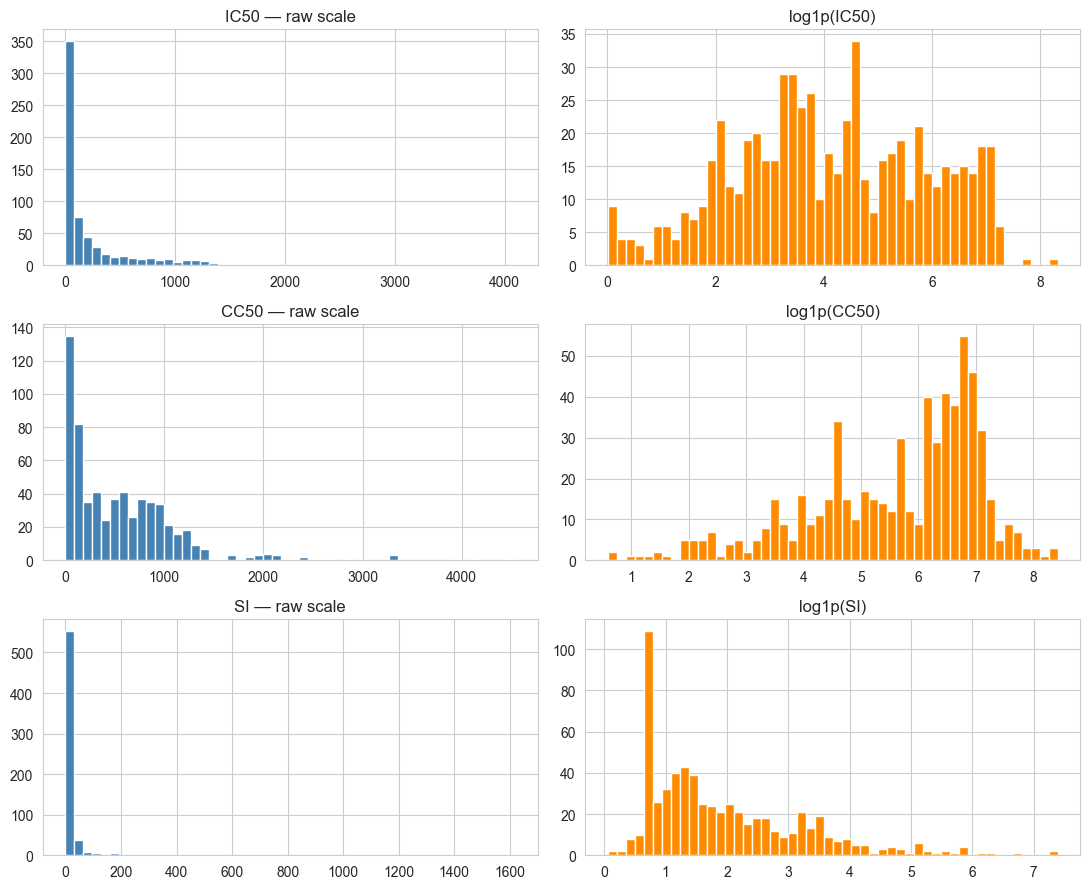

,count,mean,std,min,25%,50%,75%,max
IC50,630.0,217.466169,361.420766,0.013341,15.408535,55.989469,255.591907,4095.188563
CC50,630.0,568.519197,597.840268,0.810833,100.000113,449.988753,866.251535,4538.976189
SI,630.0,24.869958,107.042883,0.060004,1.557390,3.629536,13.328388,1618.888889


In [37]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9))
for i, col in enumerate(TARGET_COLS):
    axes[i, 0].hist(train[col], bins=50, color='steelblue')
    axes[i, 0].set_title(f'{col} — raw scale')
    axes[i, 1].hist(np.log1p(train[col]), bins=50, color='darkorange')
    axes[i, 1].set_title(f'log1p({col})')
plt.tight_layout(); plt.show()
train[TARGET_COLS].describe().T

### Тождество SI = CC50 / IC50

Проверяем, что SI в данных — это ровно отношение, а не независимая величина.

In [38]:
diff = train['SI'] - train['CC50'] / train['IC50']
print(f'max |SI - CC50/IC50| = {np.max(np.abs(diff)):.3e}')
print(f'medianа |разницы|    = {np.median(np.abs(diff)):.3e}')
print(f'corr(SI, CC50/IC50)  = {np.corrcoef(train["SI"], train["CC50"]/train["IC50"])[0, 1]:.10f}')

max |SI - CC50/IC50| = 2.149e+02
medianа |разницы|    = 4.441e-16
corr(SI, CC50/IC50)  = 0.9945040392


### Корреляции фичей с таргетами

Корреляции считаем с log1p-таргетами — устойчивее к выбросам.

In [39]:
# Формируем список признаков (все колонки, кроме целевых переменных и индекса)
feature_cols = [c for c in train.columns if c not in TARGET_COLS + [INDEX_COL]]

# Создаём матрицу признаков
X = train[feature_cols]

# Словарь для хранения корреляций для каждой целевой переменной
corrs = {}

for col in TARGET_COLS:
    # Применяем логарифмическое преобразование log(1+x) к целевой переменной
    y_log = np.log1p(train[col])
    # Вычисляем абсолютную корреляцию Пирсона между каждым признаком и целевой переменной
    corrs[col] = X.apply(lambda x: np.corrcoef(x, y_log)[0, 1]).abs().sort_values(ascending=False)

# выводим топ-15 наиболее коррелирующих признаков для каждой целевой переменной
for col in TARGET_COLS:
    print(f'=== топ-15 фичей по |corr| с log1p({col}) ===')
    print(corrs[col].head(15))
    print()

=== топ-15 фичей по |corr| с log1p(IC50) ===
NumSaturatedHeterocycles    0.243002
PEOE_VSA6                   0.242306
EState_VSA8                 0.234890
MolLogP                     0.228245
PEOE_VSA7                   0.221168
SlogP_VSA5                  0.220898
Chi2v                       0.211212
VSA_EState8                 0.208672
Chi2n                       0.205502
Kappa3                      0.198527
NumRotatableBonds           0.197861
NumAliphaticHeterocycles    0.192597
NumAliphaticCarbocycles     0.179051
EState_VSA5                 0.173099
SMR_VSA4                    0.171741
dtype: float64

=== топ-15 фичей по |corr| с log1p(CC50) ===
Kappa3              0.292196
PEOE_VSA6           0.257754
Kappa1              0.246821
fr_allylic_oxid     0.246696
Kappa2              0.241008
MolMR               0.238143
PEOE_VSA7           0.237071
Chi2v               0.235471
Chi0v               0.230847
Chi0n               0.229167
Chi0                0.227312
FpDensityMorgan1    

### Выбросы по SI

Это молекулы, на которых мы рискуем потерять больше всего в RMSE.

In [40]:
# Выбираем 10 строк с наибольшими значениями SI
top_si = train.nlargest(10, 'SI')[[INDEX_COL, 'IC50', 'CC50', 'SI']]

# Выводим таблицу с топ-10
print('топ-10 по si:')
print(top_si.to_string(index=False))

# Вычисляем и выводим 95-й процентиль и максимальное значение SI
print(f'\n95% квантиль si = {train["SI"].quantile(0.95):.1f}, max = {train["SI"].max():.1f}')

топ-10 по si:
 index     IC50        CC50          SI
 699.0 0.030886   50.001030 1618.888889
 142.0 0.589523  921.129231 1562.500000
 400.0 0.085895   71.201365  828.935484
  23.0 3.537791 1965.439708  555.555556
 411.0 0.200452  100.000703  500.000000
 469.0 6.687877 2388.527425  357.142857
 616.0 0.729727   99.998194  351.961806
 541.0 0.298932   99.999046  334.521277
 593.0 0.013341    4.399321  329.750000
 354.0 4.745148  664.320666  312.500000

95% квантиль si = 83.9, max = 1618.9


## Обучение моделей

### Хелперы

In [41]:
# ── lightgbm out-of-fold предсказания ──────────────────────────────────────────────────────

def lgb_oof(X, y_raw, params, n_rounds=3000, early=100):
    """
    Выполняет out-of-fold предсказания для регрессии с помощью lightgbm.

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_raw : array-like
        Исходные целевые значения (до преобразования)
    params : dict
        Гиперпараметры lightgbm
    n_rounds : int, default=3000
        Максимальное количество деревьев
    early : int, default=100
        Количество раундов без улучшения для ранней остановки

    Возвращает:
    -----------
    oof_pred : array
        out-of-fold предсказания на тренировочных данных
    test_pred : array
        Предсказания на тестовых данных (усреднённые по всем фолдам)
    """
    # Применяем логарифмическое преобразование к целевой переменной
    y_log = log1p_target(y_raw)

    # Массивы для хранения предсказаний
    oof_log = np.zeros(len(X))      # oof предсказания в логарифмическом масштабе
    test_log = np.zeros(len(X_test)) # Тестовые предсказания в логарифмическом масштабе

    # Кросс-валидация по фолдам
    for tr_idx, va_idx in kf.split(X):
        dtr = lgb.Dataset(X[tr_idx], y_log[tr_idx])
        dva = lgb.Dataset(X[va_idx], y_log[va_idx], reference=dtr)

        m = lgb.train({**params, 'seed': SEED, 'verbose': -1}, dtr, n_rounds,
                      valid_sets=[dva],
                      callbacks=[lgb.early_stopping(early), lgb.log_evaluation(0)])

        oof_log[va_idx] = m.predict(X[va_idx], num_iteration=m.best_iteration)

        test_log += m.predict(X_test, num_iteration=m.best_iteration) / N_FOLDS

    return np.clip(expm1_pred(oof_log), 0, None), np.clip(expm1_pred(test_log), 0, None)


def lgb_clf_oof(X, y_label, params, n_rounds=500, early=50):
    """
    Выполняет out-of-fold предсказания для классификации с помощью lightgbm.

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_label : array-like
        Бинарные метки классов (0/1)
    params : dict
        Гиперпараметры lightgbm
    n_rounds : int, default=500
        Максимальное количество деревьев
    early : int, default=50
        Количество раундов без улучшения для ранней остановки

    Возвращает:
    -----------
    oof_prob : array
        out-of-fold вероятности на тренировочных данных
    test_prob : array
        Вероятности на тестовых данных (усреднённые по всем фолдам)
    """
    # Массивы для хранения вероятностей
    oof_prob = np.zeros(len(X))      # oof вероятности
    test_prob = np.zeros(len(X_test)) # Тестовые вероятности

    # Кросс-валидация по фолдам
    for tr_idx, va_idx in kf.split(X):
        dtr = lgb.Dataset(X[tr_idx], y_label[tr_idx])
        dva = lgb.Dataset(X[va_idx], y_label[va_idx], reference=dtr)

        m = lgb.train({**params, 'seed': SEED, 'verbose': -1}, dtr, n_rounds,
                      valid_sets=[dva],
                      callbacks=[lgb.early_stopping(early), lgb.log_evaluation(0)])

        oof_prob[va_idx] = m.predict(X[va_idx])
        test_prob += m.predict(X_test) / N_FOLDS

    return oof_prob, test_prob

In [42]:
# ── xgboost out-of-fold предсказания ───────────────────────────────────────────────────────

def xgb_oof(X, y_raw, params, n_rounds=3000, early=100):
    """
    Выполняет out-of-fold предсказания для регрессии с помощью xgboost.

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_raw : array-like
        Исходные целевые значения (до преобразования)
    params : dict
        Гиперпараметры xgboost
    n_rounds : int, default=3000
        Максимальное количество деревьев
    early : int, default=100
        Количество раундов без улучшения для ранней остановки

    Возвращает:
    -----------
    oof_pred : array
        out-of-fold предсказания на тренировочных данных
    test_pred : array
        Предсказания на тестовых данных (усреднённые по всем фолдам)
    """
    # Применяем логарифмическое преобразование к целевой переменной
    y_log = log1p_target(y_raw)

    # Массивы для хранения предсказаний
    oof_log = np.zeros(len(X))      # oof предсказания в логарифмическом масштабе
    test_log = np.zeros(len(X_test)) # Тестовые предсказания в логарифмическом масштабе

    # Кросс-валидация по фолдам
    for tr_idx, va_idx in kf.split(X):
        dtrain = xgb.DMatrix(X[tr_idx], y_log[tr_idx])
        dval = xgb.DMatrix(X[va_idx], y_log[va_idx])

        m = xgb.train({**params, 'seed': SEED, 'verbosity': 0}, dtrain, n_rounds,
                      evals=[(dval, 'val')], early_stopping_rounds=early,
                      verbose_eval=False)

        oof_log[va_idx] = m.predict(dval)
        test_log += m.predict(xgb.DMatrix(X_test)) / N_FOLDS

    return np.clip(expm1_pred(oof_log), 0, None), np.clip(expm1_pred(test_log), 0, None)


def xgb_oof_weighted(X, y_raw, params, weights, n_rounds=3000, early=100):
    """
    Выполняет out-of-fold предсказания для регрессии с весами образцов.

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_raw : array-like
        Исходные целевые значения (до преобразования)
    params : dict
        Гиперпараметры xgboost
    weights : array-like
        Веса для каждого тренировочного образца
    n_rounds : int, default=3000
        Максимальное количество деревьев
    early : int, default=100
        Количество раундов без улучшения для ранней остановки

    Возвращает:
    -----------
    oof_pred : array
        out-of-fold предсказания на тренировочных данных
    test_pred : array
        Предсказания на тестовых данных (усреднённые по всем фолдам)
    """
    # Применяем логарифмическое преобразование к целевой переменной
    y_log = log1p_target(y_raw)

    # Массивы для хранения предсказаний
    oof_log = np.zeros(len(X))
    test_log = np.zeros(len(X_test))

    # Кросс-валидация по фолдам
    for tr_idx, va_idx in kf.split(X):
        dtrain = xgb.DMatrix(X[tr_idx], y_log[tr_idx], weight=weights[tr_idx])
        dval = xgb.DMatrix(X[va_idx], y_log[va_idx])

        m = xgb.train({**params, 'seed': SEED, 'verbosity': 0}, dtrain, n_rounds,
                      evals=[(dval, 'val')], early_stopping_rounds=early,
                      verbose_eval=False)

        oof_log[va_idx] = m.predict(dval)
        test_log += m.predict(xgb.DMatrix(X_test)) / N_FOLDS

    return np.clip(expm1_pred(oof_log), 0, None), np.clip(expm1_pred(test_log), 0, None)


def xgb_clf_oof(X, y_label, params, n_rounds=500, early=50):
    """
    Выполняет out-of-fold предсказания для классификации с помощью xgboost.

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_label : array-like
        Бинарные метки классов (0/1)
    params : dict
        Гиперпараметры xgboost (objective и eval_metric переопределяются)
    n_rounds : int, default=500
        Максимальное количество деревьев
    early : int, default=50
        Количество раундов без улучшения для ранней остановки

    Возвращает:
    -----------
    oof_prob : array
        out-of-fold вероятности на тренировочных данных
    test_prob : array
        Вероятности на тестовых данных (усреднённые по всем фолдам)
    """
    # Массивы для хранения вероятностей
    oof_prob = np.zeros(len(X))
    test_prob = np.zeros(len(X_test))

    # Кросс-валидация по фолдам
    for tr_idx, va_idx in kf.split(X):
        dtrain = xgb.DMatrix(X[tr_idx], y_label[tr_idx])
        dval = xgb.DMatrix(X[va_idx], y_label[va_idx])

        m = xgb.train({**params, 'seed': SEED, 'verbosity': 0,
                       'objective': 'binary:logistic', 'eval_metric': 'auc'},
                      dtrain, n_rounds,
                      evals=[(dval, 'val')], early_stopping_rounds=early,
                      verbose_eval=False)

        oof_prob[va_idx] = m.predict(dval)
        test_prob += m.predict(xgb.DMatrix(X_test)) / N_FOLDS

    return oof_prob, test_prob

In [43]:
# ── Optuna: оптимизация гиперпараметров ────────────────────────────────────────────────────

def tune_xgb_reg(X, y_raw, n_trials=N_TRIALS_REG, label=''):
    """
    Выполняет поиск оптимальных гиперпараметров для xgboost (регрессия).

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_raw : array-like
        Исходные целевые значения
    n_trials : int, default=N_TRIALS_REG
        Количество итераций optuna
    label : str, default=''
        Метка для вывода (например, 'ic50')

    Возвращает:
    -----------
    dict
        Словарь с оптимальными гиперпараметрами
    """
    # Применяем логарифмическое преобразование к целевой переменной
    y_log = log1p_target(y_raw)

    # Целевая функция для optuna
    def objective(trial):
        # Определяем пространство поиска гиперпараметров
        p = {
            'objective': 'reg:squarederror', 'eval_metric': 'rmse',
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 9),
            'min_child_weight':  trial.suggest_int('min_child_weight', 1, 50),
            'subsample':         trial.suggest_float('subsample', 0.4, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1.0),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 20.0, log=True),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'gamma':             trial.suggest_float('gamma', 0, 5),
            'seed': SEED, 'verbosity': 0,
        }

        # Кросс-валидация для оценки качества
        scores = []
        for tr_idx, va_idx in kf.split(X):
            dtrain = xgb.DMatrix(X[tr_idx], y_log[tr_idx])
            dval   = xgb.DMatrix(X[va_idx], y_log[va_idx])
            m = xgb.train(p, dtrain, 3000,
                          evals=[(dval, 'val')], early_stopping_rounds=100,
                          verbose_eval=False)
            # Преобразуем предсказания обратно в исходный масштаб
            pred = np.clip(expm1_pred(m.predict(dval)), 0, None)
            scores.append(rmse(y_raw[va_idx], pred))

        # Возвращаем средний rmse по фолдам
        return np.mean(scores)

    # Создаём и запускаем optuna study
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'[{label}] best oof rmse: {study.best_value:.4f}')
    return {'objective': 'reg:squarederror', 'eval_metric': 'rmse', **study.best_params}


def tune_xgb_clf(X, y_label, n_trials=N_TRIALS_CLF, label=''):
    """
    Выполняет поиск оптимальных гиперпараметров для xgboost (классификация).

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_label : array-like
        Бинарные метки классов (0/1)
    n_trials : int, default=N_TRIALS_CLF
        Количество итераций optuna
    label : str, default=''
        Метка для вывода

    возвращает:
    -----------
    dict
        Словарь с оптимальными гиперпараметрами
    """
    def objective(trial):
        p = {
            'objective': 'binary:logistic', 'eval_metric': 'auc',
            'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'max_depth':        trial.suggest_int('max_depth', 2, 7),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 30),
            'subsample':        trial.suggest_float('subsample', 0.4, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.01, 20.0, log=True),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 20.0),
            'seed': SEED, 'verbosity': 0,
        }

        oof_prob = np.zeros(len(X))
        for tr_idx, va_idx in kf.split(X):
            dtrain = xgb.DMatrix(X[tr_idx], y_label[tr_idx])
            dval   = xgb.DMatrix(X[va_idx], y_label[va_idx])
            m = xgb.train(p, dtrain, 500,
                          evals=[(dval, 'val')], early_stopping_rounds=50,
                          verbose_eval=False)
            oof_prob[va_idx] = m.predict(dval)

        # Возвращаем отрицательный roc-auc (optuna минимизирует)
        return -roc_auc_score(y_label, oof_prob)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'[{label} clf] best roc-auc: {-study.best_value:.4f}')
    return {'objective': 'binary:logistic', 'eval_metric': 'auc', **study.best_params}


def tune_lgb_reg(X, y_raw, n_trials=N_TRIALS_REG, label=''):
    """
    Выполняет поиск оптимальных гиперпараметров для lightgbm (регрессия).

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_raw : array-like
        Исходные целевые значения
    n_trials : int, default=N_TRIALS_REG
        Количество итераций optuna
    label : str, default=''
        Метка для вывода

    Возвращает:
    -----------
    dict
        Словарь с оптимальными гиперпараметрами
    """
    y_log = log1p_target(y_raw)

    def objective(trial):
        p = {
            'objective': 'regression', 'metric': 'rmse', 'verbose': -1,
            'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'num_leaves':       trial.suggest_int('num_leaves', 20, 200),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
            'max_depth':        trial.suggest_int('max_depth', 3, 9),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.3, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.3, 1.0),
            'bagging_freq':     trial.suggest_int('bagging_freq', 1, 10),
            'lambda_l1':        trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
            'lambda_l2':        trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        }

        scores = []
        for tr_idx, va_idx in kf.split(X):
            dtr = lgb.Dataset(X[tr_idx], y_log[tr_idx])
            dva = lgb.Dataset(X[va_idx], y_log[va_idx], reference=dtr)
            m = lgb.train(p, dtr, 3000, valid_sets=[dva],
                          callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
            pred = np.clip(expm1_pred(
                m.predict(X[va_idx], num_iteration=m.best_iteration)), 0, None)
            scores.append(rmse(y_raw[va_idx], pred))

        return np.mean(scores)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'[{label}] best oof rmse: {study.best_value:.4f}')
    return {'objective': 'regression', 'metric': 'rmse', **study.best_params}


def tune_lgb_clf(X, y_label, n_trials=N_TRIALS_CLF, label=''):
    """
    Выполняет поиск оптимальных гиперпараметров для lightgbm (классификация).

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_label : array-like
        Бинарные метки классов (0/1)
    n_trials : int, default=N_TRIALS_CLF
        Количество итераций optuna
    label : str, default=''
        Метка для вывода

    Возвращает:
    -----------
    dict
        Словарь с оптимальными гиперпараметрами
    """
    def objective(trial):
        p = {
            'objective': 'binary', 'metric': 'binary_logloss',
            'is_unbalance': True, 'verbose': -1,
            'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.3, 1.0),
            'lambda_l1':        trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
            'lambda_l2':        trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        }

        oof_prob = np.zeros(len(X))
        for tr_idx, va_idx in kf.split(X):
            dtr = lgb.Dataset(X[tr_idx], y_label[tr_idx])
            dva = lgb.Dataset(X[va_idx], y_label[va_idx], reference=dtr)
            m = lgb.train(p, dtr, 500, valid_sets=[dva],
                          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
            oof_prob[va_idx] = m.predict(X[va_idx])

        return -roc_auc_score(y_label, oof_prob)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'[{label} clf] best roc-auc: {-study.best_value:.4f}')
    return {'objective': 'binary', 'metric': 'binary_logloss',
            'is_unbalance': True, **study.best_params}

In [44]:
# ── Кэширование артефактов (сохранение и загрузка результатов) ────────────────────────────────────────────────────

def _load_cached(name: str) -> dict | None:
    """
    Загружает кэшированные параметры из json файла.

    Параметры:
    -----------
    name : str
        Имя файла без расширения

    возвращает:
    -----------
    dict or None
        Словарь с параметрами, если файл существует и force_retune = false,
        иначе возвращает none
    """
    # Формируем полный путь к файлу артефакта
    path = ARTIFACTS_DIR / f'{ARTIFACT_PREFIX}{name}.json'

    # Если не нужно переобучать и файл существует - загружаем
    if not FORCE_RETUNE and path.exists():
        with path.open() as f:
            data = json.load(f)
        print(f'  [cache] loaded {path.name}')
        return data

    # Иначе возвращаем None (будем обучать заново)
    return None


def _save_meta(meta: dict, name: str) -> None:
    """
    Сохраняет мета-информацию (гиперпараметры, скоры) в json файл.

    Параметры:
    -----------
    meta : dict
        Словарь с сохраняемыми данными (параметры модели, скоры и т.д.)
    name : str
        Имя файла без расширения
    """
    # Формируем полный путь к файлу артефакта
    path = ARTIFACTS_DIR / f'{ARTIFACT_PREFIX}{name}.json'

    # Сохраняем данные в json с отступами для читаемости
    with path.open('w') as f:
        json.dump(meta, f, indent=2)

    print(f'  [cache] saved  {path.name}')

In [45]:
# ── Двухэтапный xgboost (классификация + регрессия) ─────────────────────────────────────────────────

def twostage_xgb(X, y_raw, thr, label,
                 n_trials_reg=N_TRIALS_REG, n_trials_clf=N_TRIALS_CLF):
    """
    Реализует двухэтапный подход для предсказания:
    1. Классификация: определяет, относится ли соединение к "экстремальным" (выше порога)
    2. Регрессия 1: модель для обычных значений
    3. Регрессия 2: взвешенная модель для экстремальных значений
    Финальное предсказание = (1 - p) * pred_normal + p * pred_extreme

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_raw : array-like
        Исходные целевые значения
    thr : float
        Порог для разделения на обычные и экстремальные значения
    label : str
        Метка для вывода (например, 'ic50')
    n_trials_reg : int, default=N_TRIALS_REG
        Количество итераций optuna для регрессии
    n_trials_clf : int, default=N_TRIALS_CLF
        Количество итераций optuna для классификации

    Возвращает:
    -----------
    oof_ts : array
        out-of-fold предсказания на тренировочных данных (двухэтапные)
    test_ts : array
        Предсказания на тестовых данных (двухэтапные)
    meta : dict
        Мета-информация: параметры моделей, скоры, порог
    """
    # Создаём бинарную метку: 1 если значение выше порога (экстремальное), иначе 0
    y_label = (y_raw > thr).astype(int)
    n_extreme = y_label.sum()

    # Выводим информацию о распределении классов
    print(f'\n--- {label} two-stage xgb (thr={thr}) ---')
    print(f'  extreme (>{thr}): {n_extreme} молекул ({n_extreme/len(y_raw):.1%})')

    # Пробуем загрузить кэшированные параметры
    cached = _load_cached(f'{label.lower()}_params')
    if cached:
        params_normal  = cached['params_normal']
        params_extreme = cached['params_extreme']
        params_clf     = cached['params_clf']
    else:
        # Тюним три модели
        print(f'  tuning normal xgb {label}...')
        params_normal  = tune_xgb_reg(X, y_raw, n_trials_reg, f'{label} normal')

        print(f'  tuning extreme xgb {label}...')
        params_extreme = tune_xgb_reg(X, y_raw, n_trials_reg, f'{label} extreme')

        print(f'  tuning classifier {label}...')
        params_clf     = tune_xgb_clf(X, y_label, n_trials_clf, label)

    # Веса для экстремальной модели: пропорциональны sqrt(y) (больший вес для больших значений)
    weights_sqrt = np.sqrt(y_raw) / np.sqrt(y_raw).mean()

    # Получаем предсказания от трёх моделей
    oof_normal,  test_normal  = xgb_oof(X, y_raw, params_normal)           # обычная регрессия
    oof_extreme, test_extreme = xgb_oof_weighted(X, y_raw, params_extreme, weights_sqrt)  # взвешенная регрессия
    oof_prob,    test_prob    = xgb_clf_oof(X, y_label, params_clf)        # классификатор (вероятность экстремальности)

    # Выводим метрики качества каждой модели
    print(f'  normal oof rmse:    {rmse(y_raw, oof_normal):.4f}')
    print(f'  extreme max pred:   {oof_extreme.max():.1f}  (true max: {y_raw.max():.1f})')
    print(f'  classifier roc-auc: {roc_auc_score(y_label, oof_prob):.4f}')

    # Комбинируем предсказания: взвешиваем по вероятности из классификатора
    # Чем выше вероятность, что значение экстремальное, тем больше вклад extreme модели
    oof_ts  = (1 - oof_prob)  * oof_normal  + oof_prob  * oof_extreme
    test_ts = (1 - test_prob) * test_normal + test_prob * test_extreme

    print(f'  two-stage oof rmse: {rmse(y_raw, oof_ts):.4f}')

    # Сохраняем мета-информацию
    meta = {
        'params_normal':  params_normal,
        'params_extreme': params_extreme,
        'params_clf':     params_clf,
        'threshold':      thr,
        'rmse_normal':    float(rmse(y_raw, oof_normal)),
        'rmse_twostage':  float(rmse(y_raw, oof_ts)),
        'clf_auc':        float(roc_auc_score(y_label, oof_prob)),
    }

    if not cached:
        _save_meta(meta, f'{label.lower()}_params')

    return oof_ts, test_ts, meta

In [46]:
# ── Двухэтапный lightgbm для SI ───────────────────────────────────────────

def twostage_lgb_si(X, y_raw, thr,
                    n_trials_reg=N_TRIALS_REG, n_trials_clf=N_TRIALS_CLF):
    """
    Двухэтапный подход для SI с использованием lightgbm.

    Особенность: для экстремальной регрессии используется полный обучающий набор,
    а не out-of-fold, потому что молекул с SI > 200 очень мало (всего 16 штук)
    и честная кросс-валидация даёт нестабильные результаты.

    Параметры:
    -----------
    X : array-like
        Матрица признаков
    y_raw : array-like
        Исходные значения SI
    thr : float
        Порог для разделения на обычные и экстремальные значения (SI > thr)
    n_trials_reg : int, default=N_TRIALS_REG
        Количество итераций optuna для регрессии
    n_trials_clf : int, default=N_TRIALS_CLF
        Количество итераций optuna для классификации

    Возвращает:
    -----------
    oof_ts : array
        out-of-fold предсказания на тренировочных данных (двухэтапные)
    test_ts : array
        Предсказания на тестовых данных (двухэтапные)
    meta : dict
        Мета-информация: параметры моделей, скоры, порог
    """
    # Создаём бинарную метку: 1 если SI выше порога (экстремальное), иначе 0
    y_label = (y_raw > thr).astype(int)
    n_extreme = y_label.sum()

    print(f'\n--- si two-stage lgb (thr={thr}) ---')
    print(f'  extreme (>{thr}): {n_extreme} молекул ({n_extreme/len(y_raw):.1%})')

    # Пробуем загрузить кэшированные параметры
    cached = _load_cached('si_params')
    if cached:
        params_normal  = cached['params_normal']
        params_extreme = cached['params_extreme']
        params_clf     = cached['params_clf']
    else:
        print('  tuning normal lgb si...')
        params_normal  = tune_lgb_reg(X, y_raw, n_trials_reg, 'si normal')

        print('  tuning extreme lgb si...')
        params_extreme = tune_lgb_reg(X, y_raw, n_trials_reg, 'si extreme')

        print('  tuning classifier si...')
        params_clf     = tune_lgb_clf(X, y_label, n_trials_clf, 'si')

    # Обычная модель: честные oof предсказания
    oof_normal, test_normal = lgb_oof(X, y_raw, params_normal)
    print(f'  normal oof rmse: {rmse(y_raw, oof_normal):.4f}')

    # Экстремальная модель: обучаем на всех данных (не oof)
    # Причина: слишком мало экстремальных молекул для стабильной кросс-валидации
    y_log = log1p_target(y_raw)
    weights_sqrt = np.sqrt(y_raw) / np.sqrt(y_raw).mean()  # веса для акцента на больших значениях

    ext_model = lgb.train(
        {**params_extreme, 'seed': SEED, 'verbose': -1},
        lgb.Dataset(X, y_log, weight=weights_sqrt),
        num_boost_round=1000,
    )

    # Предсказываем на всех тренировочных и тестовых данных
    oof_extreme  = np.clip(expm1_pred(ext_model.predict(X)),      0, None)
    test_extreme = np.clip(expm1_pred(ext_model.predict(X_test)), 0, None)
    print(f'  extreme max pred: {oof_extreme.max():.1f}  (true max: {y_raw.max():.1f})')

    # Классификатор: честные oof предсказания (вероятность принадлежности к экстремальным)
    oof_prob, test_prob = lgb_clf_oof(X, y_label, params_clf)
    print(f'  classifier roc-auc: {roc_auc_score(y_label, oof_prob):.4f}')

    # Комбинируем предсказания: взвешиваем по вероятности из классификатора
    oof_ts  = (1 - oof_prob)  * oof_normal  + oof_prob  * oof_extreme
    test_ts = (1 - test_prob) * test_normal + test_prob * test_extreme

    print(f'  two-stage oof rmse: {rmse(y_raw, oof_ts):.4f}')

    # Сохраняем мета-информацию
    meta = {
        'params_normal':  params_normal,
        'params_extreme': params_extreme,
        'params_clf':     params_clf,
        'threshold':      thr,
        'rmse_normal':    float(rmse(y_raw, oof_normal)),
        'rmse_twostage':  float(rmse(y_raw, oof_ts)),
        'clf_auc':        float(roc_auc_score(y_label, oof_prob)),
    }

    if not cached:
        _save_meta(meta, 'si_params')

    return oof_ts, test_ts, meta

### IC50 — Two-stage XGBoost (порог 500)

102 молекулы с IC50 > 500 дают **91% MSE**.

In [47]:
# Выполняет двухэтапное обучение модели xgboost для предсказания ic50
oof_ic50, test_ic50, ic50_meta = twostage_xgb(
    X_train, y_ic50, thr=THR_IC50, label='IC50',
)

# Выводим итоговую ошибку rmse на тренировочных данных (out-of-fold)
print(f'\nIC50 final OOF RMSE: {rmse(y_ic50, oof_ic50):.4f}')


--- IC50 two-stage xgb (thr=500) ---
  extreme (>500): 94 молекул (14.9%)
  [cache] loaded final_ic50_params.json
  normal oof rmse:    312.1524
  extreme max pred:   2144.7  (true max: 4095.2)
  classifier roc-auc: 0.8011
  two-stage oof rmse: 323.3830

IC50 final OOF RMSE: 323.3830


### CC50 — Two-stage XGBoost (порог 1500)

104 молекулы с CC50 > 1500 дают ~60% MSE.

In [48]:
oof_cc50, test_cc50, cc50_meta = twostage_xgb(
    X_train, y_cc50, thr=THR_CC50, label='CC50',
)
print(f'\nCC50 final OOF RMSE: {rmse(y_cc50, oof_cc50):.4f}')


--- CC50 two-stage xgb (thr=1500) ---
  extreme (>1500): 31 молекул (4.9%)
  [cache] loaded final_cc50_params.json
  normal oof rmse:    444.6782
  extreme max pred:   3720.5  (true max: 4539.0)
  classifier roc-auc: 0.9214
  two-stage oof rmse: 438.5725

CC50 final OOF RMSE: 438.5725


### SI — Two-stage LightGBM (порог 200)

16 молекул с SI > 200 дают **100% MSE**.
Extreme регрессор обучается на полном train.

In [49]:
oof_si, test_si, si_meta = twostage_lgb_si(
    X_train, y_si, thr=THR_SI,
)
print(f'\nSI final OOF RMSE: {rmse(y_si, oof_si):.4f}')


--- si two-stage lgb (thr=200) ---
  extreme (>200): 13 молекул (2.1%)
  [cache] loaded final_si_params.json
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[29]	valid_0's rmse: 1.04747
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[29]	valid_0's rmse: 1.17867
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[33]	valid_0's rmse: 1.15344
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[50]	valid_0's rmse: 1.10063
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[143]	valid_0's rmse: 1.09958
  normal oof rmse: 102.5567
  extreme max pred: 1607.5  (true max: 1618.9)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0854603
Training until validation scores don't improve f

### Итоговые метрики

In [50]:
scores = competition_score(y_ic50, oof_ic50, y_cc50, oof_cc50, y_si, oof_si)

print('OOF scores:')
for k, v in scores.items():
    print(f'  {k:12s} = {v:.4f}')

print()

print(f'OOF={scores["score"]:.2f}')

OOF scores:
  rmse_ic50    = 323.3830
  rmse_cc50    = 438.5725
  rmse_si      = 99.4035
  score        = 287.1196

OOF=287.12


## Сборка final_submission.csv

In [51]:
# Сохраняем итоговые скоры (rmse для ic50, cc50, si) в json файл
with (ARTIFACTS_DIR / f'{ARTIFACT_PREFIX}scores.json').open('w') as f:
    # Преобразуем все значения в float для корректной сериализации в json
    json.dump({k: float(v) for k, v in scores.items()}, f, indent=2)

# Создаём датафрейм для сабмита
submission = pd.DataFrame({
    'index': test[INDEX_COL],   # идентификатор соединения
    'ic50':  test_ic50,         # предсказанные значения ic50
    'cc50':  test_cc50,         # предсказанные значения cc50
    'si':    test_si,           # предсказанные значения si
})

# Формируем путь для сохранения файла сабмита
sub_path = SUBMISSIONS_DIR / f'{ARTIFACT_PREFIX}submission.csv'
submission.to_csv(sub_path, index=False)  # Сохраняем без индекса

# Короткий путь для вывода
short_path = sub_path.relative_to(REPO_ROOT)

# Выводим информацию о созданном файле
print(f'submission: ./{short_path} (path relative to repo_root)')

# Выводим статистику предсказанных значений для контроля
print(f'ic50: min={test_ic50.min():.3f}  max={test_ic50.max():.1f}  mean={test_ic50.mean():.1f}')
print(f'cc50: min={test_cc50.min():.3f}  max={test_cc50.max():.1f}  mean={test_cc50.mean():.1f}')
print(f'si:   min={test_si.min():.3f}   max={test_si.max():.1f}   mean={test_si.mean():.1f}')

submission: ./data/submissions/final_submission.csv (path relative to repo_root)
ic50: min=2.025  max=3057.9  mean=176.3
cc50: min=11.327  max=3443.2  mean=525.1
si:   min=1.347   max=118.4   mean=11.5
